# SGCRL Four Rooms Maze Visualization

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.animation as animation
from IPython.display import HTML, display

# Set up matplotlib for inline display
plt.ion()
%matplotlib inline

## Environment Setup


In [2]:
# Configure the Four Rooms Maze
HEIGHT, WIDTH = 10, 10
GOAL_COORD = (9, 9)  # row 9, col 9 (zero-indexed)
walls = np.zeros((HEIGHT, WIDTH), dtype=int)
DOOR_LEN = 2

# Create horizontal wall
walls[HEIGHT // 2, :] = 1
doors_h = np.concatenate(
    [WIDTH // 4 + np.arange(DOOR_LEN), WIDTH * 3 // 4 + np.arange(DOOR_LEN)]
)
walls[HEIGHT // 2, doors_h] = 0

# Create vertical wall
walls[:, WIDTH // 2] = 1
doors_v = np.concatenate(
    [HEIGHT // 4 + np.arange(DOOR_LEN), HEIGHT * 3 // 4 + np.arange(DOOR_LEN)]
)
walls[doors_v, WIDTH // 2] = 0

# Environment parameters
NUM_STATES = HEIGHT * WIDTH
NUM_ACTIONS = 5  # stay, down, up, right, left
A_TO_DELTA = np.array([[0, 0], [1, 0], [-1, 0], [0, 1], [0, -1]])
START_STATE = np.ravel_multi_index((0, 0), walls.shape)
GOAL_STATE = np.ravel_multi_index(GOAL_COORD, walls.shape)

print(f"Four Rooms Maze Environment Setup:")
print(f"   Grid size: {HEIGHT}x{WIDTH}")
print(f"   Number of states: {NUM_STATES}")
print(f"   Number of actions: {NUM_ACTIONS}")
print(f"   Start state: {START_STATE} -> {np.unravel_index(START_STATE, walls.shape)}")
print(f"   Goal state: {GOAL_STATE} -> {np.unravel_index(GOAL_STATE, walls.shape)}")


def step(state: int, action: int) -> int:
    """Deterministic step function for the maze."""
    di, dj = A_TO_DELTA[action]
    i, j = np.unravel_index(state, walls.shape)
    ni, nj = i + di, j + dj
    if 0 <= ni < HEIGHT and 0 <= nj < WIDTH and walls[ni, nj] == 0:
        return np.ravel_multi_index((ni, nj), walls.shape)
    return state  # blocked: stay in place


def is_near_goal(s):
    """Check if state is near the goal (within Manhattan distance 1)"""
    si, sj = np.unravel_index(s, walls.shape)
    gi, gj = np.unravel_index(GOAL_STATE, walls.shape)
    return abs(si - gi) + abs(sj - gj) <= 1

Four Rooms Maze Environment Setup:
   Grid size: 10x10
   Number of states: 100
   Number of actions: 5
   Start state: 0 -> (np.int64(0), np.int64(0))
   Goal state: 99 -> (np.int64(9), np.int64(9))


## SGCRL Agent Implementation

In [3]:
class SGCRLAgent:
    """
    State-Goal Contrastive Reinforcement Learning Agent for Maze
    """

    def __init__(
        self,
        nState,
        nAction,
        rep_dim=16,
        episodes_per_upd=5,
        lr_psi=1e-3,
        replay_capacity=1000,
        max_steps=100,
        batch_size=128,
        gamma=0.99,
        entropy_coeff=0.1,
        max_episodes=50000,
        plot_freq=100,
    ):
        """
        Initialize SGCRL agent for Maze

        Args:
            nState: number of states
            nAction: number of actions
            rep_dim: representation dimension
            episodes_per_upd: episodes between representation updates
            lr_psi: learning rate for psi
            replay_capacity: maximum replay buffer size
            max_steps: maximum steps per episode
            batch_size: batch size for training
            gamma: discount factor for trajectory sampling
            entropy_coeff: entropy coefficient for action selection
            max_episodes: maximum training episodes
            plot_freq: frequency for plotting (episodes)
        """
        # Store basic parameters
        self.nState = nState
        self.nAction = nAction
        self.rep_dim = rep_dim
        self.episodes_per_upd = episodes_per_upd
        self.lr_psi = lr_psi
        self.replay_capacity = replay_capacity
        self.max_steps = max_steps
        self.batch_size = batch_size
        self.gamma = gamma
        self.entropy_coeff = entropy_coeff
        self.max_episodes = max_episodes
        self.plot_freq = plot_freq
        self.norm = True

        # Set up goal
        self.goal = GOAL_STATE

        # Initialize representation
        self.psi = np.empty((nState, rep_dim))

        # Initialize goal embedding
        self.psi_goal = np.random.randn(rep_dim) * 0.1
        self.psi[self.goal] = self.psi_goal
        if self.norm:
            psi_norm = np.linalg.norm(self.psi[self.goal]) + 1e-8
            self.psi[self.goal] /= psi_norm
            self.psi_goal /= psi_norm

        # Initialize other states
        for s in range(nState):
            if s != self.goal:
                self.psi[s] = self.psi_goal + np.random.randn(rep_dim) * 0.1

        # Normalize psi to unit vectors
        if self.norm:
            psi_norms = np.linalg.norm(self.psi, axis=1, keepdims=True) + 1e-8
            self.psi /= psi_norms

        # Replay buffer and tracking
        self.replay = []
        self.visited_states = set()
        self.visited_counts = []
        self.loss_history = []
        self.success_list = []
        self.eval_success_list = []
        self.similarity_history = []  # Store similarity plots for animation

    def select_action(self, s: int, g: int) -> int:
        """
        Softmax action selection based on ψ(s') · ψ(g) similarity,
        scaled by 1 / entropy_coeff (i.e., inverse temperature)
        """
        goal_vec = self.psi[g]

        similarities = []
        for a in range(self.nAction):
            ns = step(s, a)
            sim = self.psi[ns] @ goal_vec
            similarities.append(sim)

        # Apply entropy regularization (inverse temperature)
        logits = np.array(similarities)
        inverse_temp = 1.0 / self.entropy_coeff
        logits *= inverse_temp

        # Softmax over scaled logits
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)

        return np.random.choice(self.nAction, p=probs)

    def eval_action(self, s: int, g: int) -> int:
        """
        Deterministic evaluation policy: chooses the action with max cosine similarity
        between ψ(s') and ψ(g). No exploration or sampling.
        """
        goal_vec = self.psi[g]

        best_a = 0
        best_val = -np.inf

        for a in range(self.nAction):
            ns = step(s, a)
            ns_vec = self.psi[ns]
            val = ns_vec @ goal_vec
            if val > best_val:
                best_val = val
                best_a = a

        return best_a

    def collect_episode(self):
        """Generate one trajectory and push into replay buffer."""
        step_success = []
        traj = [START_STATE]
        for _ in range(self.max_steps):
            a = self.select_action(traj[-1], self.goal)
            ns = step(traj[-1], a)
            traj.append(ns)
            success = (ns == self.goal) or is_near_goal(ns)
            step_success.append(1 if success else 0)

        self.replay.append(traj)
        if len(self.replay) > self.replay_capacity:
            self.replay.pop(0)

        return step_success

    def run_eval_episode(self):
        """Generate one evaluation trajectory."""
        success = 0
        traj = [START_STATE]
        for _ in range(self.max_steps):
            a = self.eval_action(traj[-1], self.goal)
            ns = step(traj[-1], a)
            traj.append(ns)
            success = (ns == self.goal) or is_near_goal(ns)

        return success, traj

    def update_representations(self) -> float:
        """
        Vectorised contrastive update
        """
        if len(self.replay) < 2:
            return 0.0

        traj_ids = np.random.choice(len(self.replay), self.batch_size, replace=True)
        s_list, sp_list = [], []
        for idx in traj_ids:
            traj = self.replay[idx]
            if len(traj) < 2:
                continue
            i = np.random.randint(0, len(traj) - 1)
            remaining = len(traj) - i
            w = self.gamma ** np.arange(remaining)
            w /= w.sum()
            j = i + np.random.choice(remaining, p=w)

            s_list.append(traj[i])
            sp_list.append(traj[j])

        if not s_list:
            return 0.0

        s_batch = np.asarray(s_list, dtype=np.int32)
        sp_batch = np.asarray(sp_list, dtype=np.int32)
        B = len(s_batch)

        # Gather current embeddings
        psi_s = self.psi[s_batch]
        psi_p = self.psi[sp_batch]

        # Column-wise soft-max probabilities P
        dots = psi_s @ psi_p.T
        dots -= dots.max(axis=0, keepdims=True)
        exp_logits = np.exp(dots)
        P = exp_logits / exp_logits.sum(axis=0, keepdims=True)

        diag_P = np.diag(P)
        nll = -np.mean(np.log(diag_P + 1e-12))

        # Anchor-state updates Δψ(s_j)
        coeff = np.eye(B) - P
        anchor_update = self.lr_psi * (coeff @ psi_p)
        np.add.at(self.psi, s_batch, anchor_update)

        # Positive-state updates Δψ(sp_k)
        expected_anchor = P.T @ psi_s
        pos_update = self.lr_psi * (psi_s - expected_anchor)
        np.add.at(self.psi, sp_batch, pos_update)

        # Normalize ψ to unit vectors (L2 norm)
        if self.norm:
            psi_norms = np.linalg.norm(self.psi, axis=1, keepdims=True) + 1e-8
            self.psi /= psi_norms

        return nll

    def create_similarity_plot(self, episode, eval_traj):
        """Create similarity data for animation"""
        goal_vec = self.psi[self.goal]
        goal_norm = np.linalg.norm(goal_vec) + 1e-8
        sim = (self.psi @ goal_vec) / (
            np.linalg.norm(self.psi, axis=1) * goal_norm + 1e-8
        )

        # Store similarity map and evaluation trajectory
        self.similarity_history.append((episode, sim, eval_traj))

        return None

    def train(self):
        """Main training loop"""
        for ep in tqdm(range(0, self.max_episodes), desc="Training episodes"):
            ep_success = self.collect_episode()
            self.success_list.append(np.mean(ep_success))

            for state in self.replay[-1]:
                self.visited_states.add(state)
            self.visited_counts.append(len(self.visited_states))

            # Perform SGD update every N episodes
            if ep % self.episodes_per_upd == 0:
                loss = self.update_representations()
                self.loss_history.append(loss)

            # Visualize and create plots
            if ep % self.plot_freq == 0 or ep == 0:
                eval_ep_success, eval_traj = self.run_eval_episode()
                self.eval_success_list.append(eval_ep_success)

                # Store similarity and visitation data (don't display during training)
                self.create_similarity_plot(ep, eval_traj)

    def plot_success_rate(self, window=100):
        """Plot evaluation success rate over training episodes with smoothing"""
        plt.figure(figsize=(8, 4))

        # Convert success list to binary (0 or 1)
        successes = np.array([1 if r > 0 else 0 for r in self.success_list])

        # Compute moving average
        smoothed = []
        for i in range(len(successes)):
            start_idx = max(0, i - window + 1)
            smoothed.append(np.mean(successes[start_idx : i + 1]))

        episodes = [i for i in range(len(self.success_list))]
        plt.plot(episodes, smoothed, color="tab:blue", linewidth=2)
        plt.xlabel("Training Episodes", fontsize=12)
        plt.ylabel("Success Rate", fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        return None

## Configuration and Training

Training episodes:   0%|          | 0/2000 [00:00<?, ?it/s]

Training episodes: 100%|██████████| 2000/2000 [00:25<00:00, 79.72it/s]


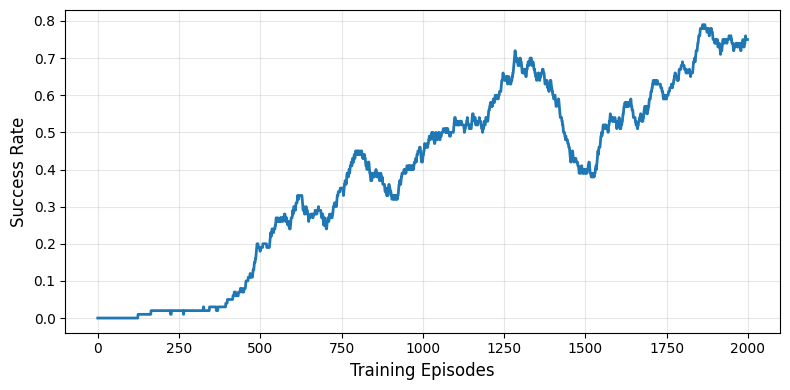

In [4]:
config = {
    "rep_dim": 16,
    "episodes_per_upd": 1,
    "lr_psi": 5e-3,
    "replay_capacity": 1000,
    "max_steps": 50,
    "batch_size": 128,
    "max_episodes": 2000,
    "gamma": 0.99,
    "entropy_coeff": 0.1,
    "plot_freq": 10,
    "seed": 42,
}

np.random.seed(config["seed"])

sgcrl_agent = SGCRLAgent(
    nState=NUM_STATES,
    nAction=NUM_ACTIONS,
    rep_dim=config["rep_dim"],
    episodes_per_upd=config["episodes_per_upd"],
    lr_psi=config["lr_psi"],
    replay_capacity=config["replay_capacity"],
    max_steps=config["max_steps"],
    batch_size=config["batch_size"],
    gamma=config["gamma"],
    entropy_coeff=config["entropy_coeff"],
    max_episodes=config["max_episodes"],
    plot_freq=config["plot_freq"],
)

sgcrl_agent.train()
sgcrl_agent.plot_success_rate()

## Visualization of Training
### In the animation, we visualize the representational similarity of each state to the goal throughout training. We also show one trajecotry collected by the SGCRL policy with entropy regularization (actor). The success rate curves are computed using success of the actor trajectories.

In [5]:
def render_maze(ax, sim_map, traj, episode_num):
    """Render maze heatmap with complete trajectory"""
    ax.clear()

    # Remove border and ticks
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    # Background: similarity heat-map
    im = ax.imshow(
        sim_map, cmap="viridis", origin="lower", vmin=min(0.0, np.min(sim_map)), vmax=1
    )

    # Overlay walls
    ax.imshow(walls, cmap=plt.cm.binary, vmin=0, vmax=1, alpha=0.5, origin="lower")

    # Draw complete trajectory
    traj_coords = np.array([np.unravel_index(s, walls.shape) for s in traj])
    if len(traj_coords) > 1:
        ax.plot(
            traj_coords[:, 1],
            traj_coords[:, 0],
            color="black",
            linewidth=2.0,
            alpha=0.8,
        )

    # Highlight start and goal
    ax.scatter(
        *np.unravel_index(START_STATE, walls.shape)[::-1],
        marker="o",
        s=200,
        c="lime",
        label="Start",
        zorder=10,
        edgecolors="black",
        linewidth=2,
        clip_on=False,
    )
    ax.scatter(
        *np.unravel_index(GOAL_STATE, walls.shape)[::-1],
        marker="*",
        s=300,
        c="red",
        label="Goal",
        zorder=10,
        edgecolors="black",
        linewidth=2,
        clip_on=False,
    )

    ax.set_title(f"Trial {episode_num}", fontsize=24)

    return im


def animate(ep_idx):
    """Animate by showing one frame per episode"""
    sim = similarities[ep_idx]
    sim_map = sim.reshape(walls.shape)
    traj = eval_trajs[ep_idx]
    episode_num = episodes[ep_idx]

    render_maze(ax, sim_map, traj, episode_num)

    return (ax,)

In [6]:
# Extract data for animation
episodes = [item[0] for item in sgcrl_agent.similarity_history]
similarities = [item[1] for item in sgcrl_agent.similarity_history]
eval_trajs = [item[2] for item in sgcrl_agent.similarity_history]

# Create figure with single plot for maze visualization
fig, ax = plt.subplots(figsize=(10, 10))

print(f"Total frames to animate: {len(episodes)}")

# One frame per episode (no step-by-step animation)
anim = animation.FuncAnimation(
    fig, animate, frames=len(episodes), interval=200, blit=False, repeat=True
)

# Increase the embed limit and optimize animation quality
plt.rcParams["animation.embed_limit"] = 100

# Save animation as gif
# anim.save('../../figures/maze_animation.gif', writer='pillow', fps=5)

# Display animation
display(HTML(anim.to_jshtml(fps=5, default_mode="loop")))
plt.close(fig)

Total frames to animate: 200
